# Logistic regression random restarts

This is the PyMC tutorial simulated logistic regression example, run in TFP.

We compare 1 MC sample and 100 MC samples over 10 random restarts. The reference lines are the best variational approximation found across all method restarts.


In [1]:
import os
from pathlib import Path
import sys

sys.path.append(os.path.abspath("../.."))

import tensorflow as tf
import tensorflow_probability as tfp

tfd = tfp.distributions
tfb = tfp.bijectors

from modulars.tfp_rr_test import tfp_run_restart_multid

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gc
from tqdm.notebook import tqdm

from modulars.logistic_regression import (
    load_logistic_regression_data,
    make_tfp_logistic_regression_conditioned_log_prob,
    plot_logistic_regression_selected_coeffs,
)
from modulars.plot_rr import plot_some_dims_multid
from modulars.utils import apply_traj_transform_multid, save_to_csv

data = load_logistic_regression_data()
labels = data["labels"]
dim = len(labels)

print(f"N observations: {len(data['y'])}")
print(f"N training observations: {len(data['y_train'])}")
print(f"N test observations: {len(data['y_test'])}")
print(f"Latent VI dimension: {dim}")
print(labels)


N observations: 250
N training observations: 175
N test observations: 75
Latent VI dimension: 4
['Intercept', 'x1', 'x2', 'x1:x2']


In [2]:
RUN_MODE = "full"  # "quick" or "full"

RUN_CONFIGS = {
    "quick": {"max_iters": 250, "n_restarts": 1, "n_particles": 100, "track_every": 10},
    "full": {"max_iters": 40_000, "n_restarts": 10, "n_particles": 100, "track_every": 10},
}

run_config = RUN_CONFIGS[RUN_MODE]
max_iters = run_config["max_iters"]
n_restarts = run_config["n_restarts"]
n_particles = run_config["n_particles"]
track_every = run_config["track_every"]

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

run_config


{'max_iters': 40000, 'n_restarts': 10, 'n_particles': 100, 'track_every': 10}

In [5]:
conditioned_log_prob = make_tfp_logistic_regression_conditioned_log_prob(data)


In [4]:
results = []
for seed in tqdm(range(n_restarts)):
    conditioned_log_prob = make_tfp_logistic_regression_conditioned_log_prob(data)
    result = tfp_run_restart_multid(
        seed=seed,
        dim=dim,
        conditioned_log_prob_fn=conditioned_log_prob,
        n_iters=max_iters,
        n_particles=n_particles,
        track_every=track_every,
    )
    results.append(result)


  0%|          | 0/10 [00:00<?, ?it/s]

I0000 00:00:1778622501.057912 9077494 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [5]:
save_to_csv(results_dir / "tfp_raw_restarts.csv", results)


In [6]:
single_means, single_stds, multi_means, multi_stds = apply_traj_transform_multid(results)
print(single_means.shape, single_stds.shape, multi_means.shape, multi_stds.shape)


  0%|          | 0/10 [00:00<?, ?it/s]

(10, 4000, 4) (10, 4000, 4) (10, 4000, 4) (10, 4000, 4)


In [7]:
save_to_csv(
    results_dir / "tfp_processed_restarts.csv",
    [(single_means, single_stds, multi_means, multi_stds)],
)

del results
gc.collect()


21

In [3]:
reference_file = Path("best_variational_reference.csv")
if not reference_file.exists():
    raise FileNotFoundError(
        "Run compute_best_reference.py after generating processed restart files."
    )

best_reference = pd.read_csv(reference_file)
reference_means = {
    row["parameter"]: [(float(row["mean"]), "best variational approximation")]
    for _, row in best_reference.iterrows()
}
reference_stds = {
    row["parameter"]: [(float(row["sd"]), "best variational approximation")]
    for _, row in best_reference.iterrows()
}
best_reference


,parameter,mean,sd,method,source_file,restart_idx,mc_setting,estimated_elbo
0,Intercept,-0.214169,0.219556,tfp,simpleVI/...,3,100_mc,-66.493148
1,x1,0.691553,0.140056,tfp,simpleVI/...,3,100_mc,-66.493148
2,x2,-0.663325,0.172611,tfp,simpleVI/...,3,100_mc,-66.493148
3,x1:x2,1.681185,0.192924,tfp,simpleVI/...,3,100_mc,-66.493148


In [4]:
from modulars.utils import load_from_csv
processed_results = load_from_csv(results_dir / "tfp_processed_restarts.csv")
single_means, single_stds, multi_means, multi_stds = processed_results[0]

In [5]:
import importlib
import modulars.logistic_regression
importlib.reload(modulars.logistic_regression)

<module 'modulars.logistic_regression' from 'modulars/logistic_regression.py'>

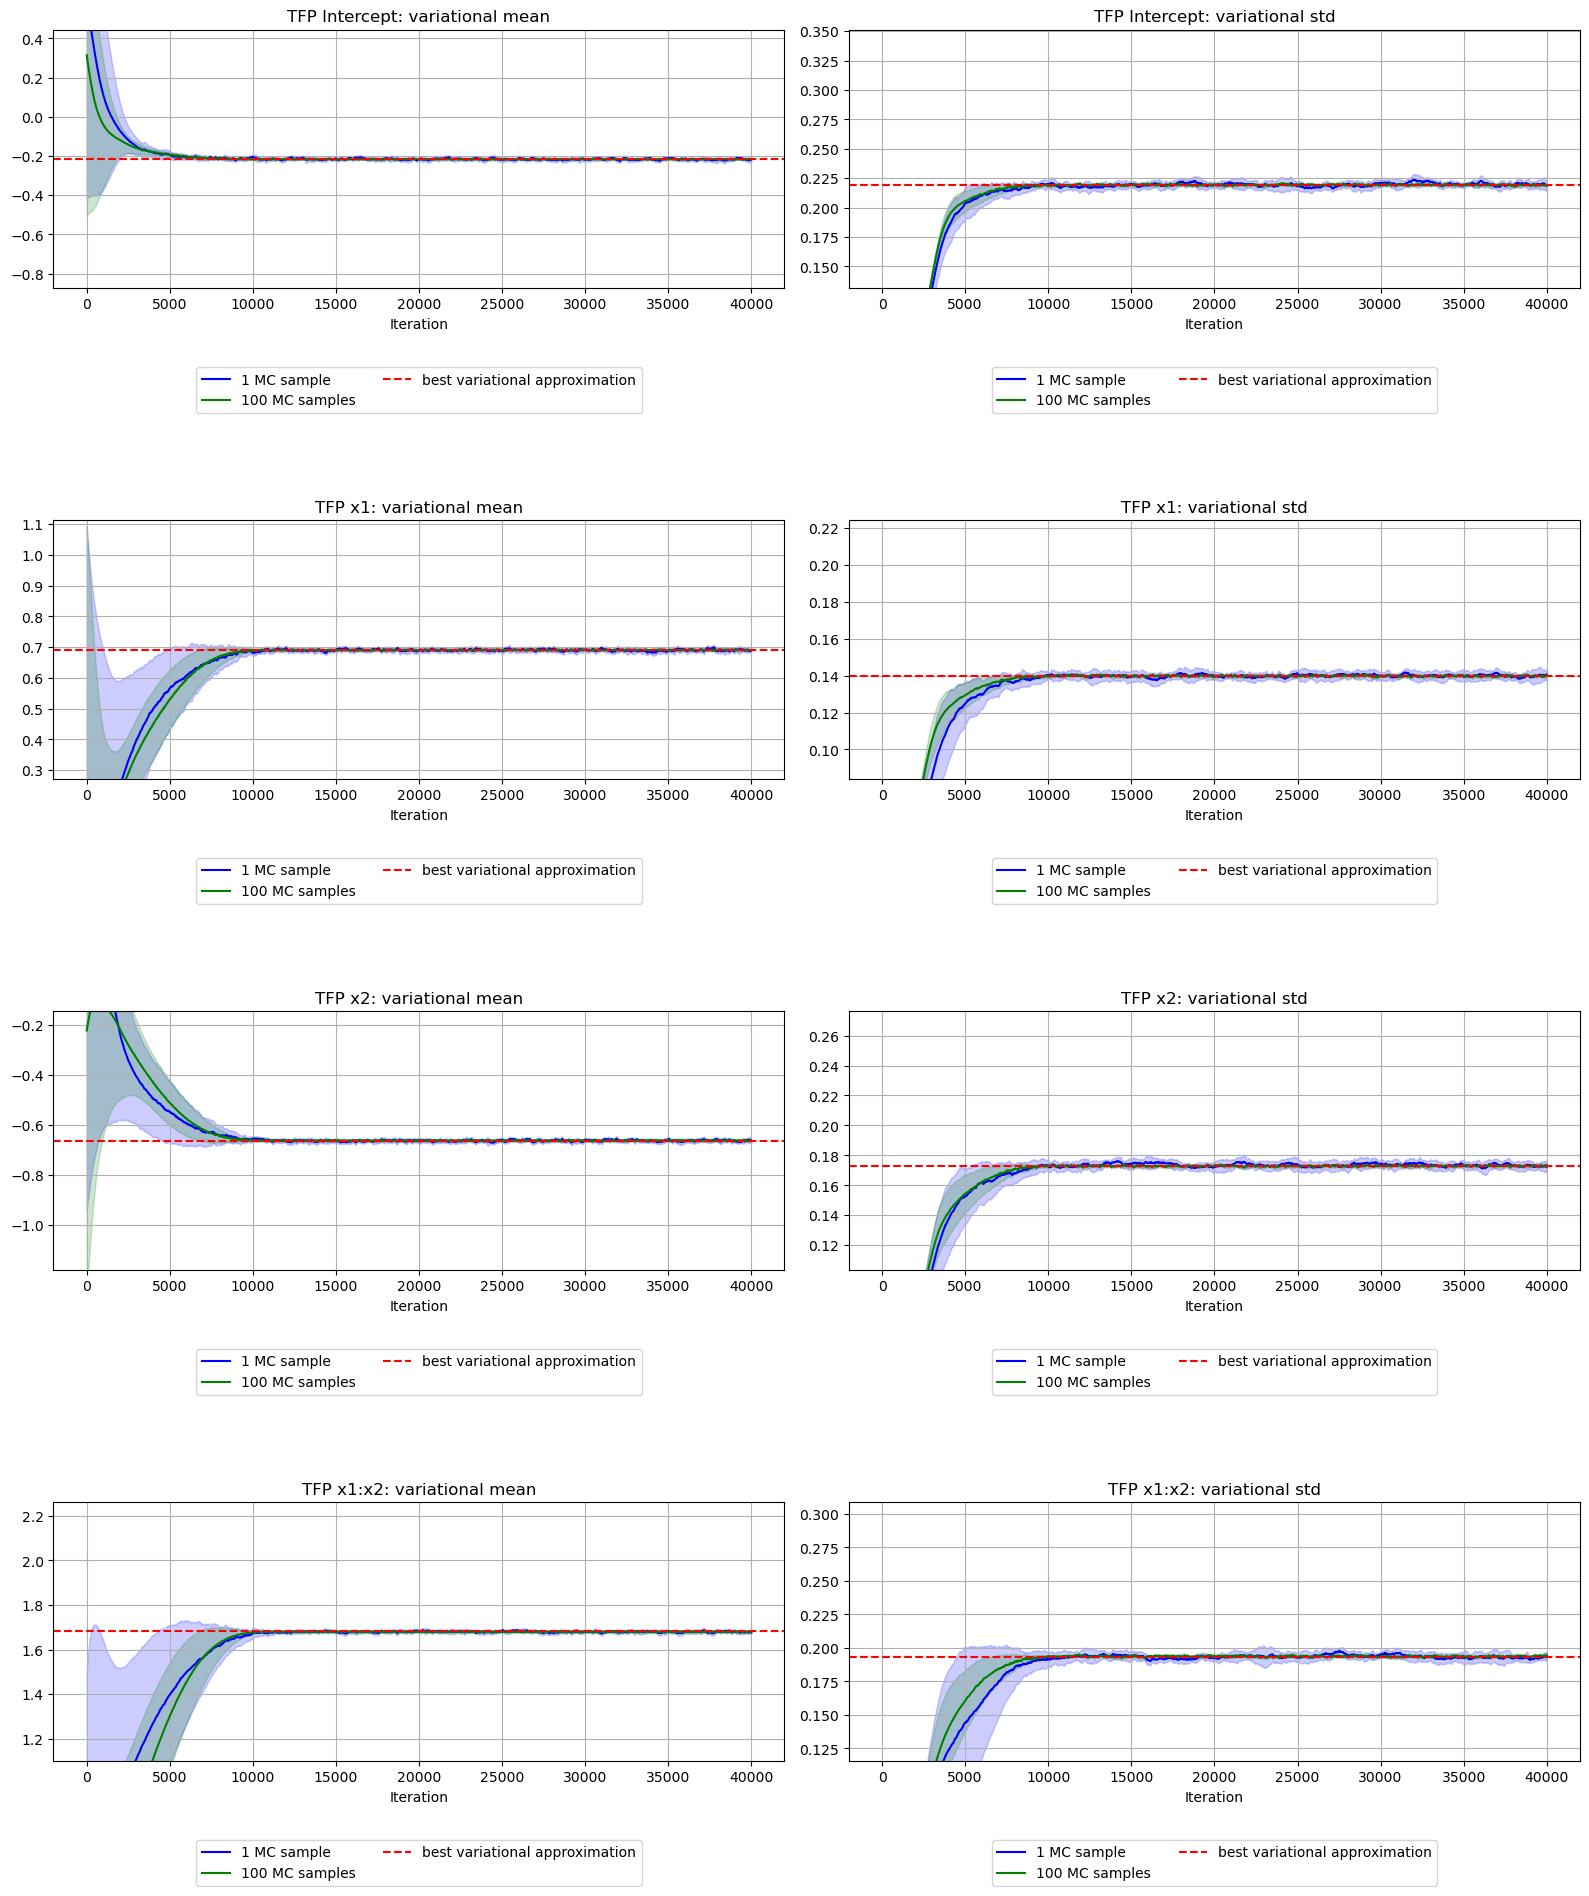

In [6]:
modulars.logistic_regression.plot_logistic_regression_selected_coeffs_zoomed(
    single_means, single_stds, multi_means, multi_stds,
    labels=labels,
    title_prefix="TFP ",
    reference_means=reference_means,
    reference_stds=reference_stds,
    iteration_stride=track_every
)

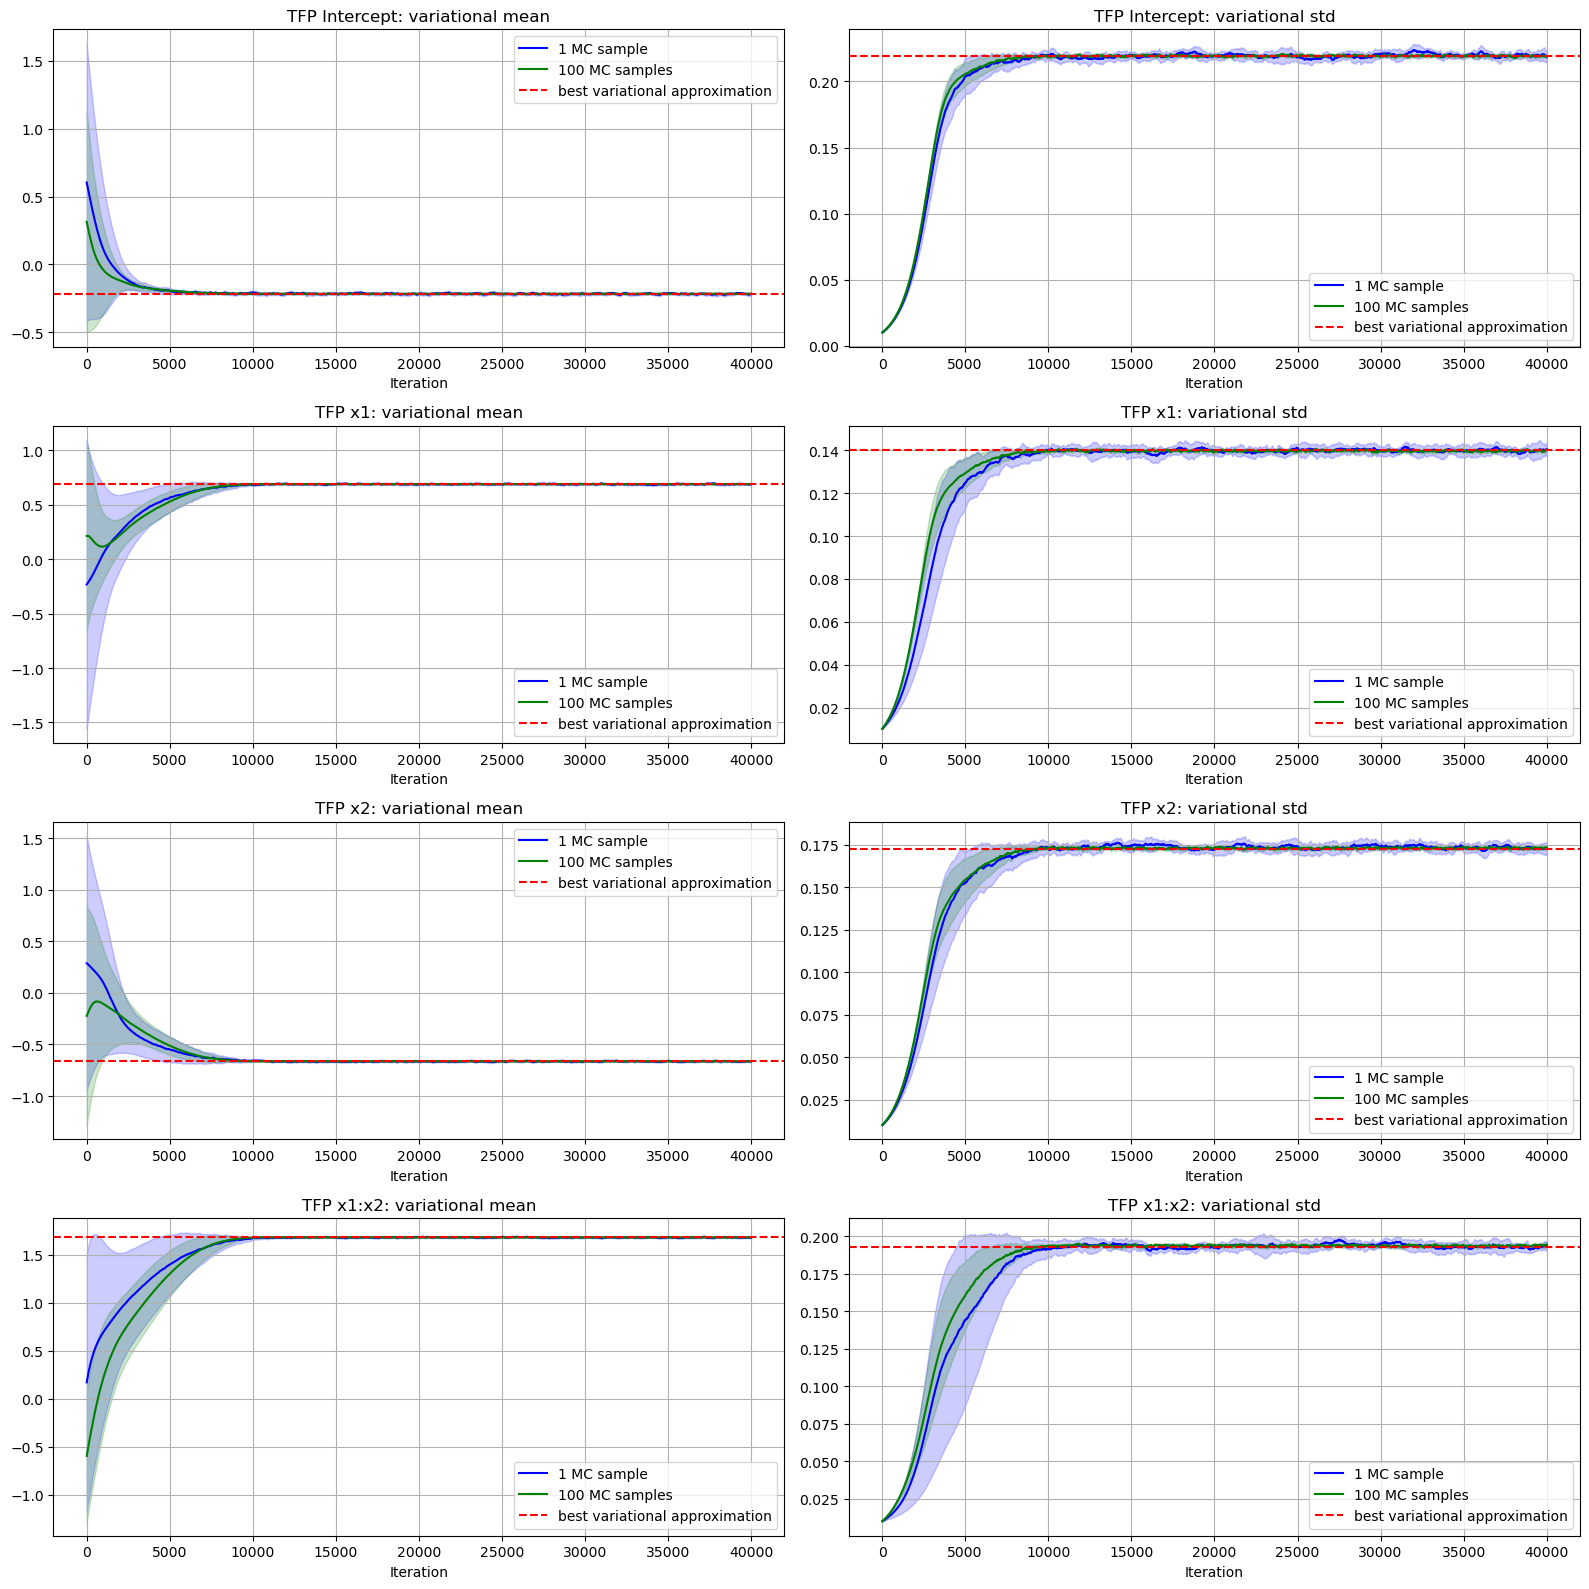

In [11]:
modulars.logistic_regression.plot_logistic_regression_selected_coeffs(
    single_means, single_stds, multi_means, multi_stds,
    labels=labels,
    title_prefix="TFP ",
    reference_means=reference_means,
    reference_stds=reference_stds,
    iteration_stride=track_every
)


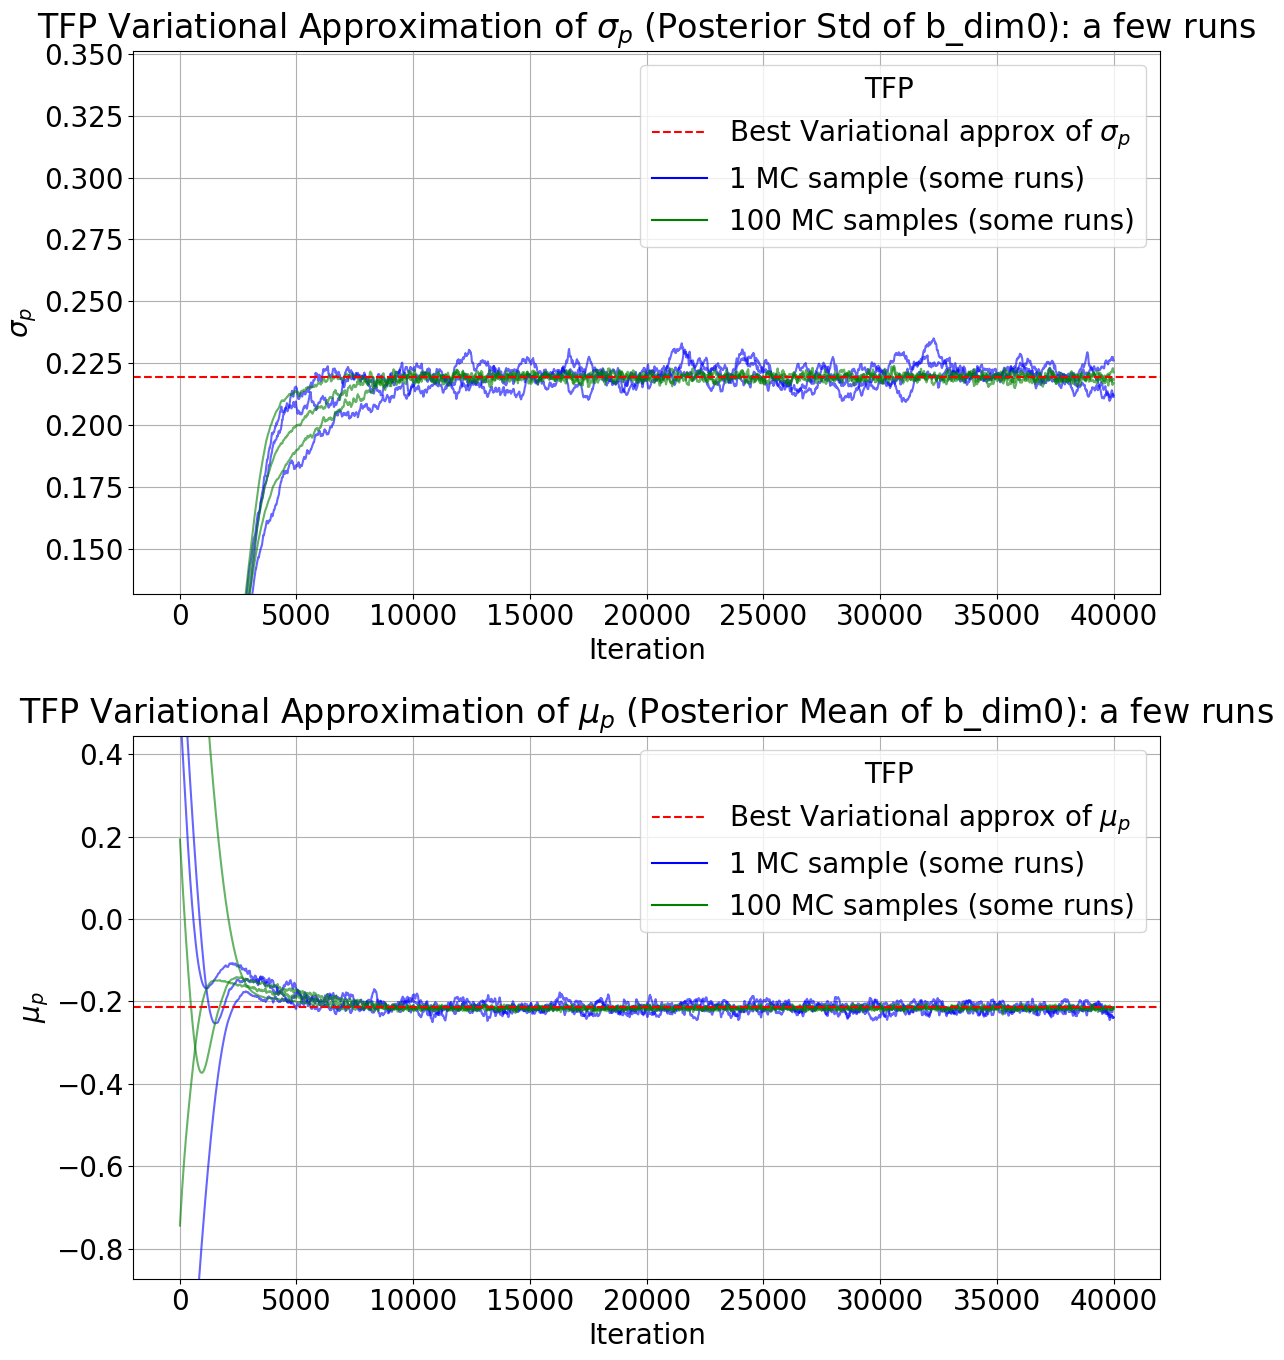

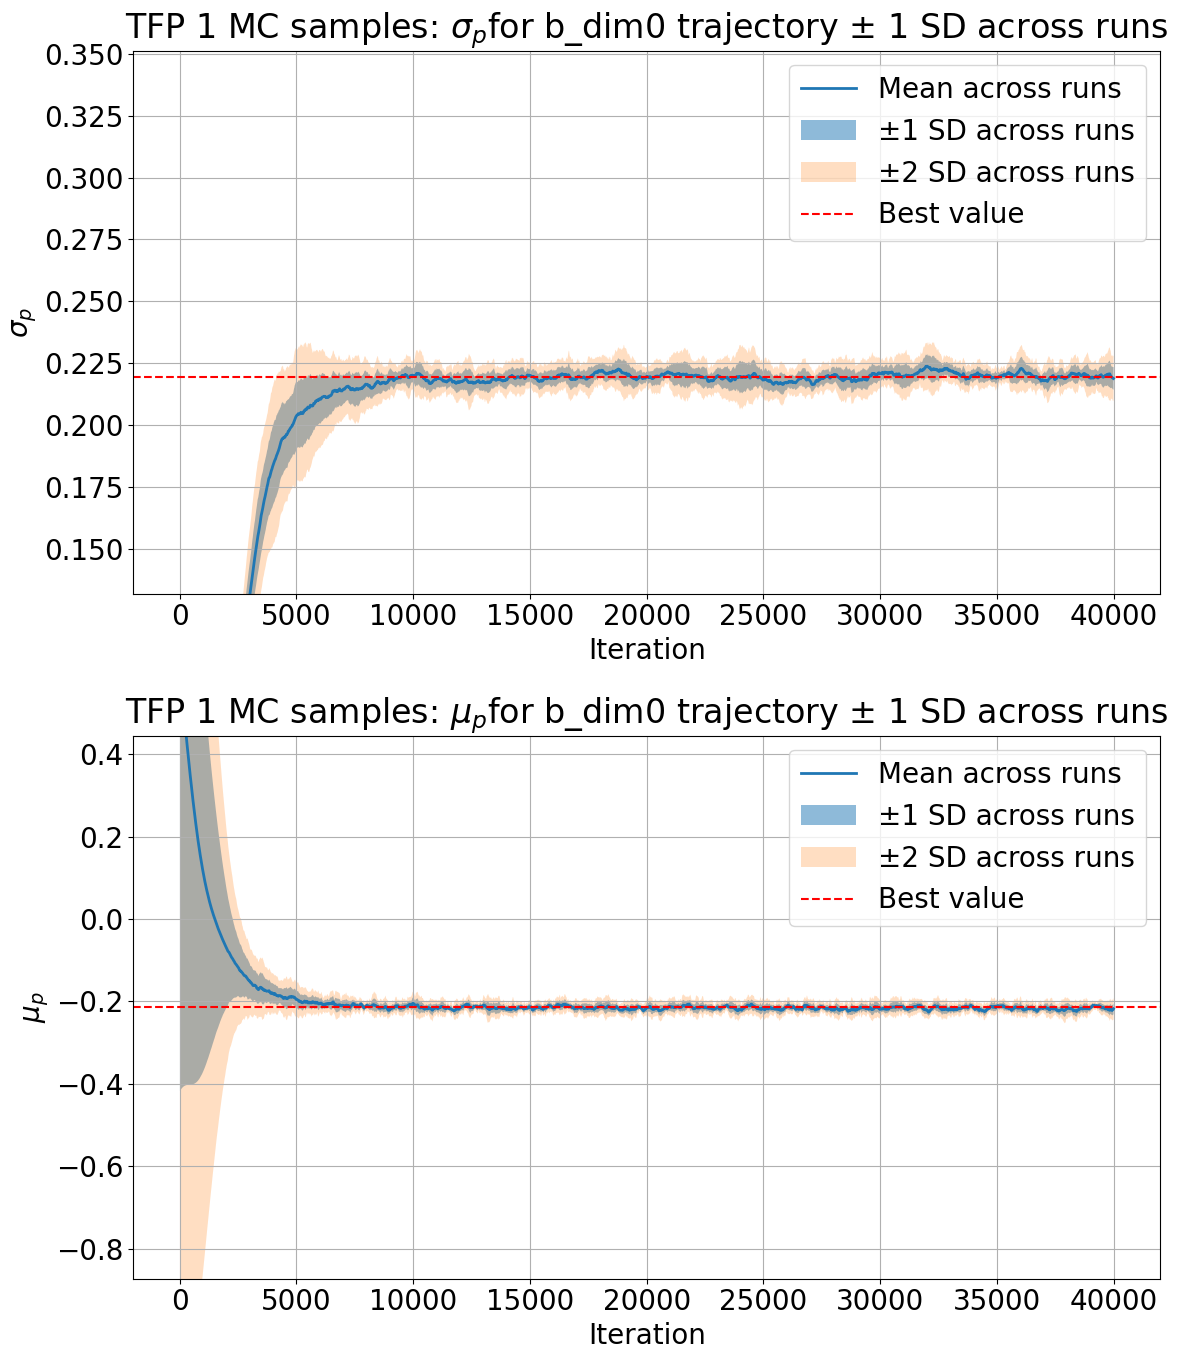

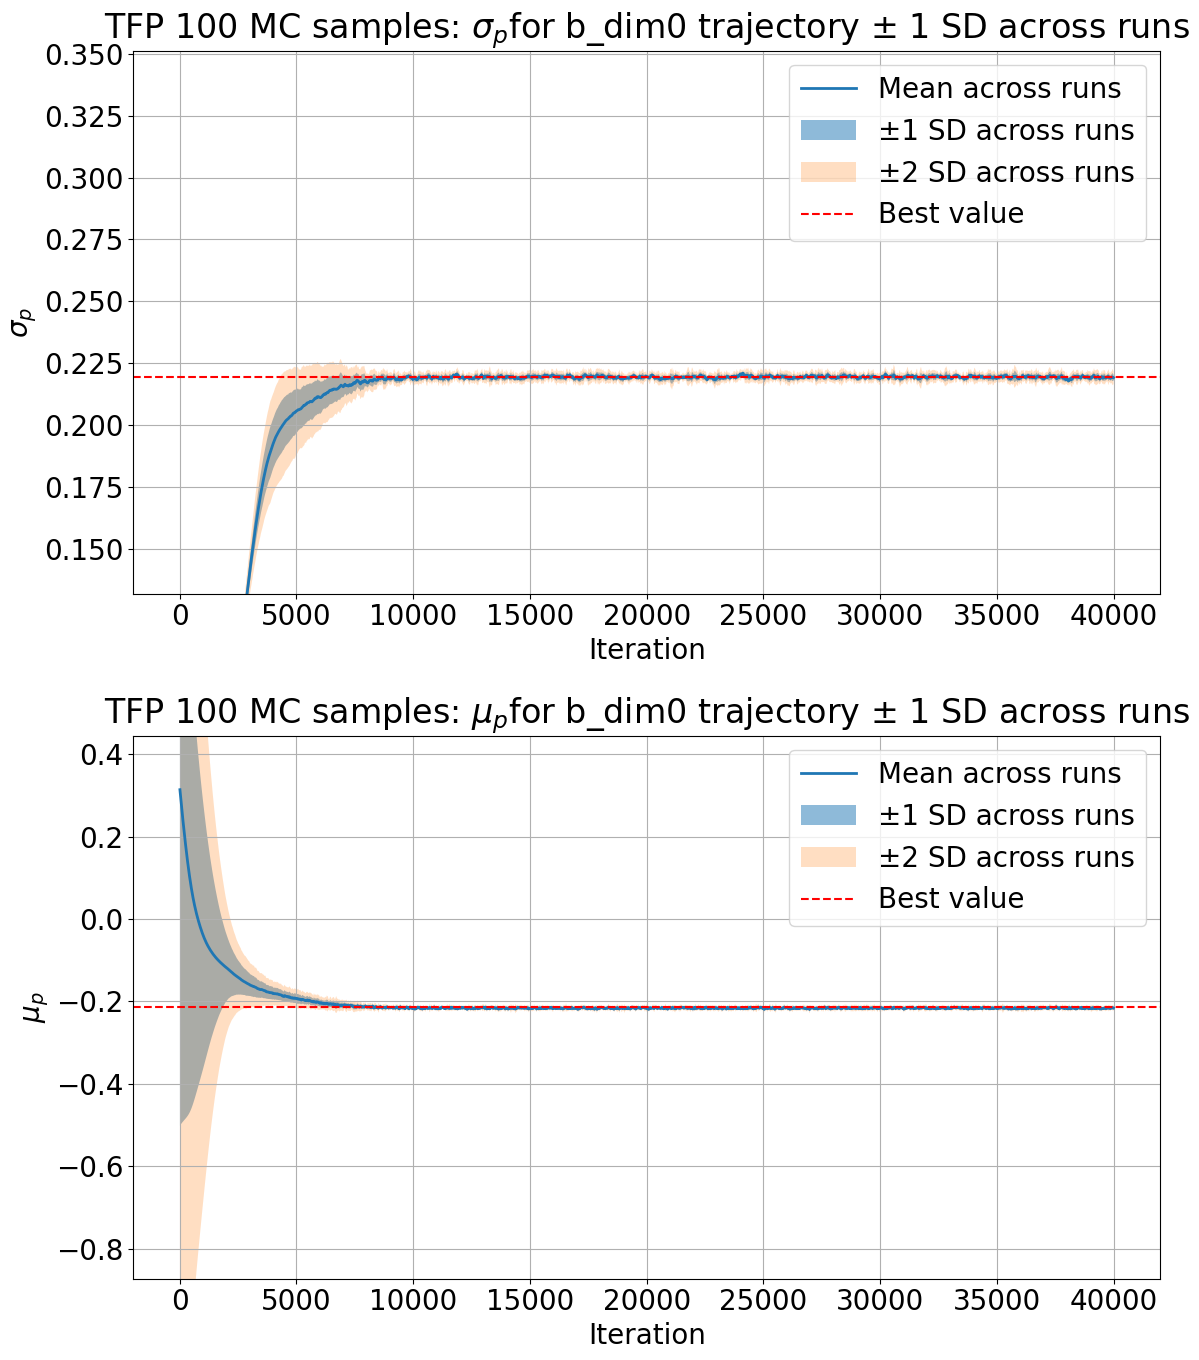

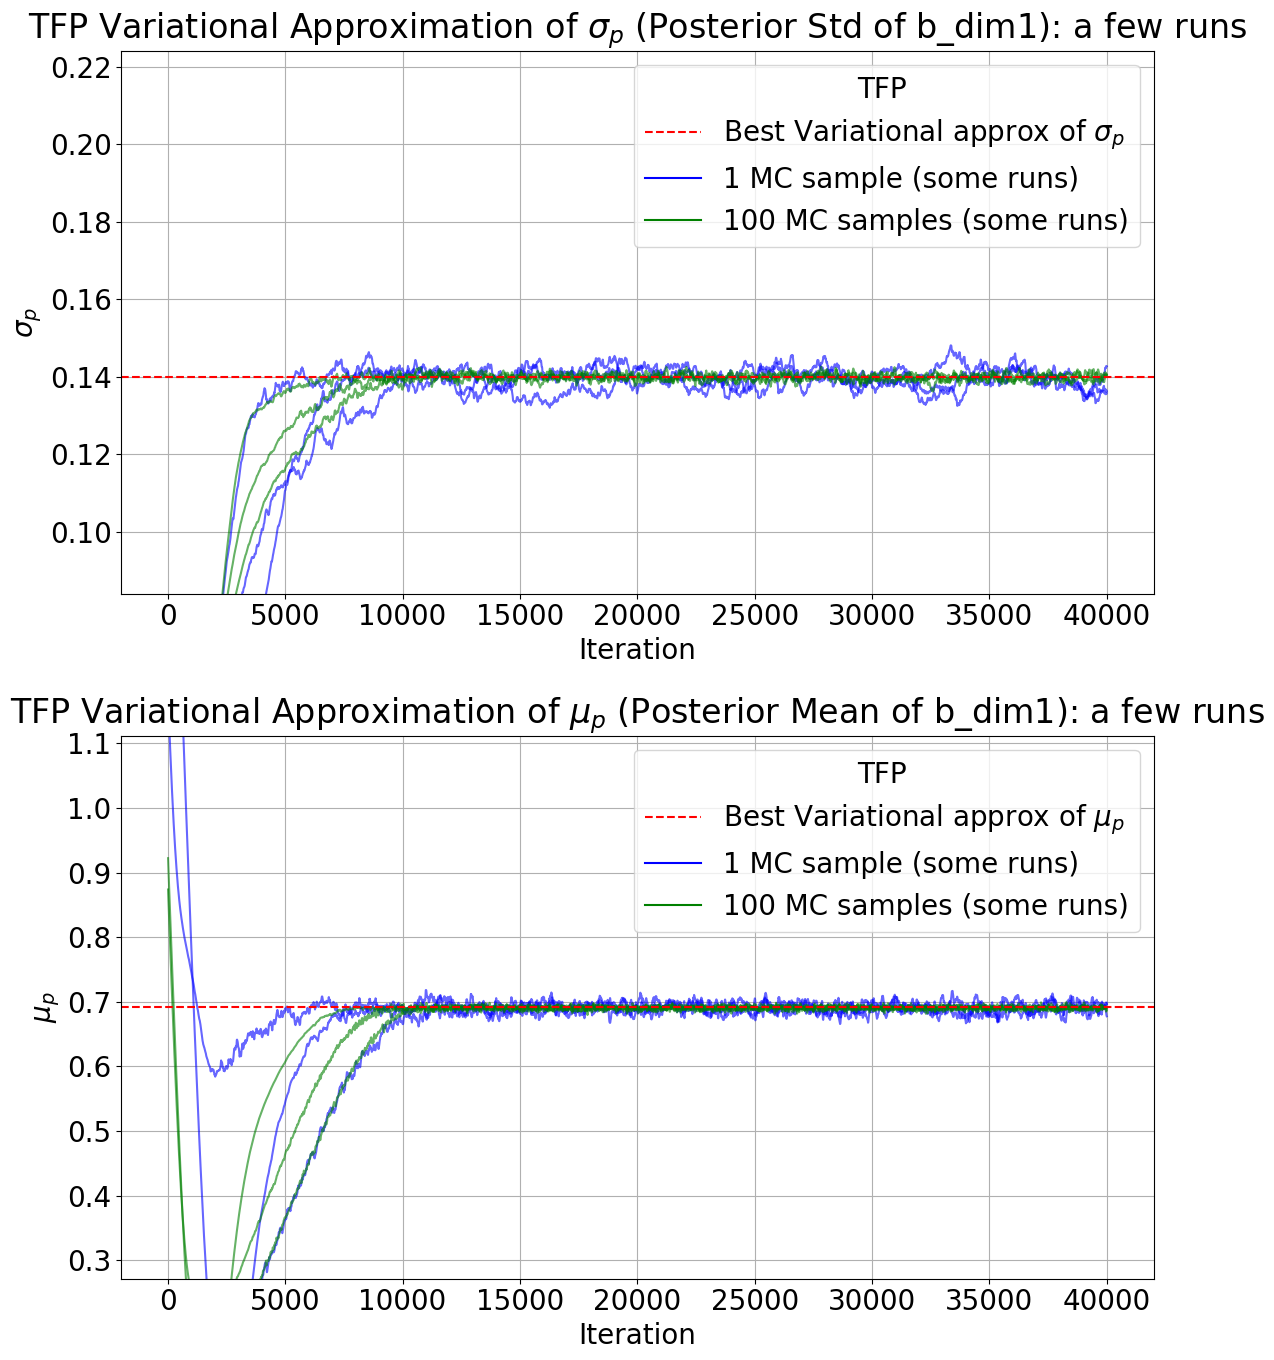

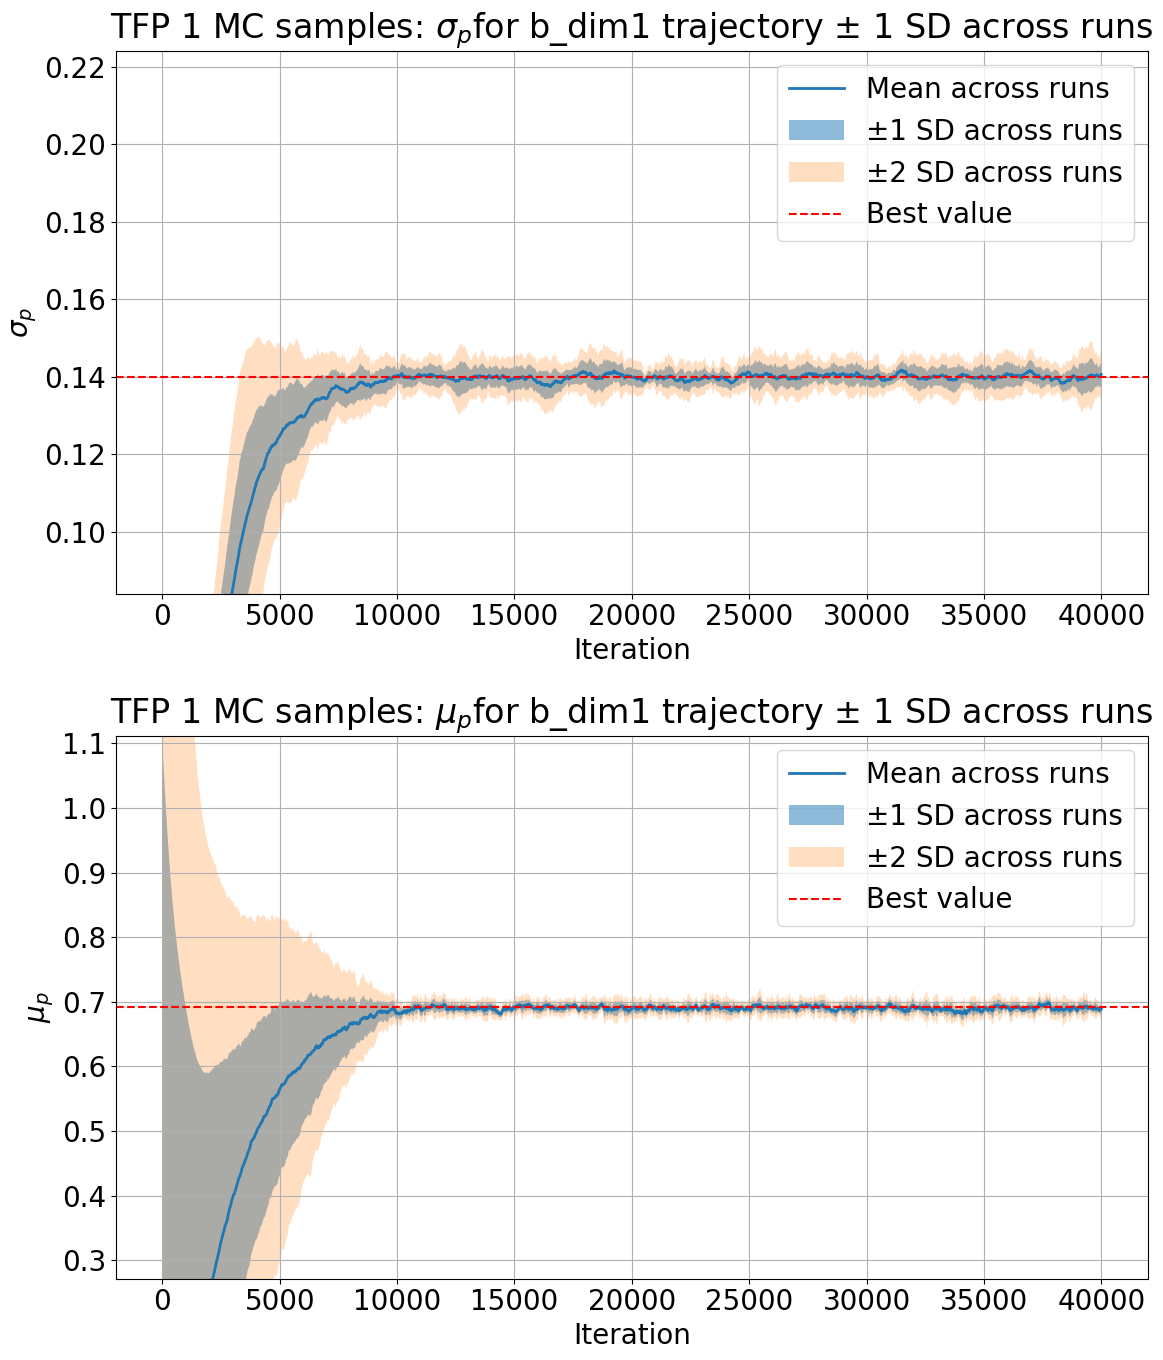

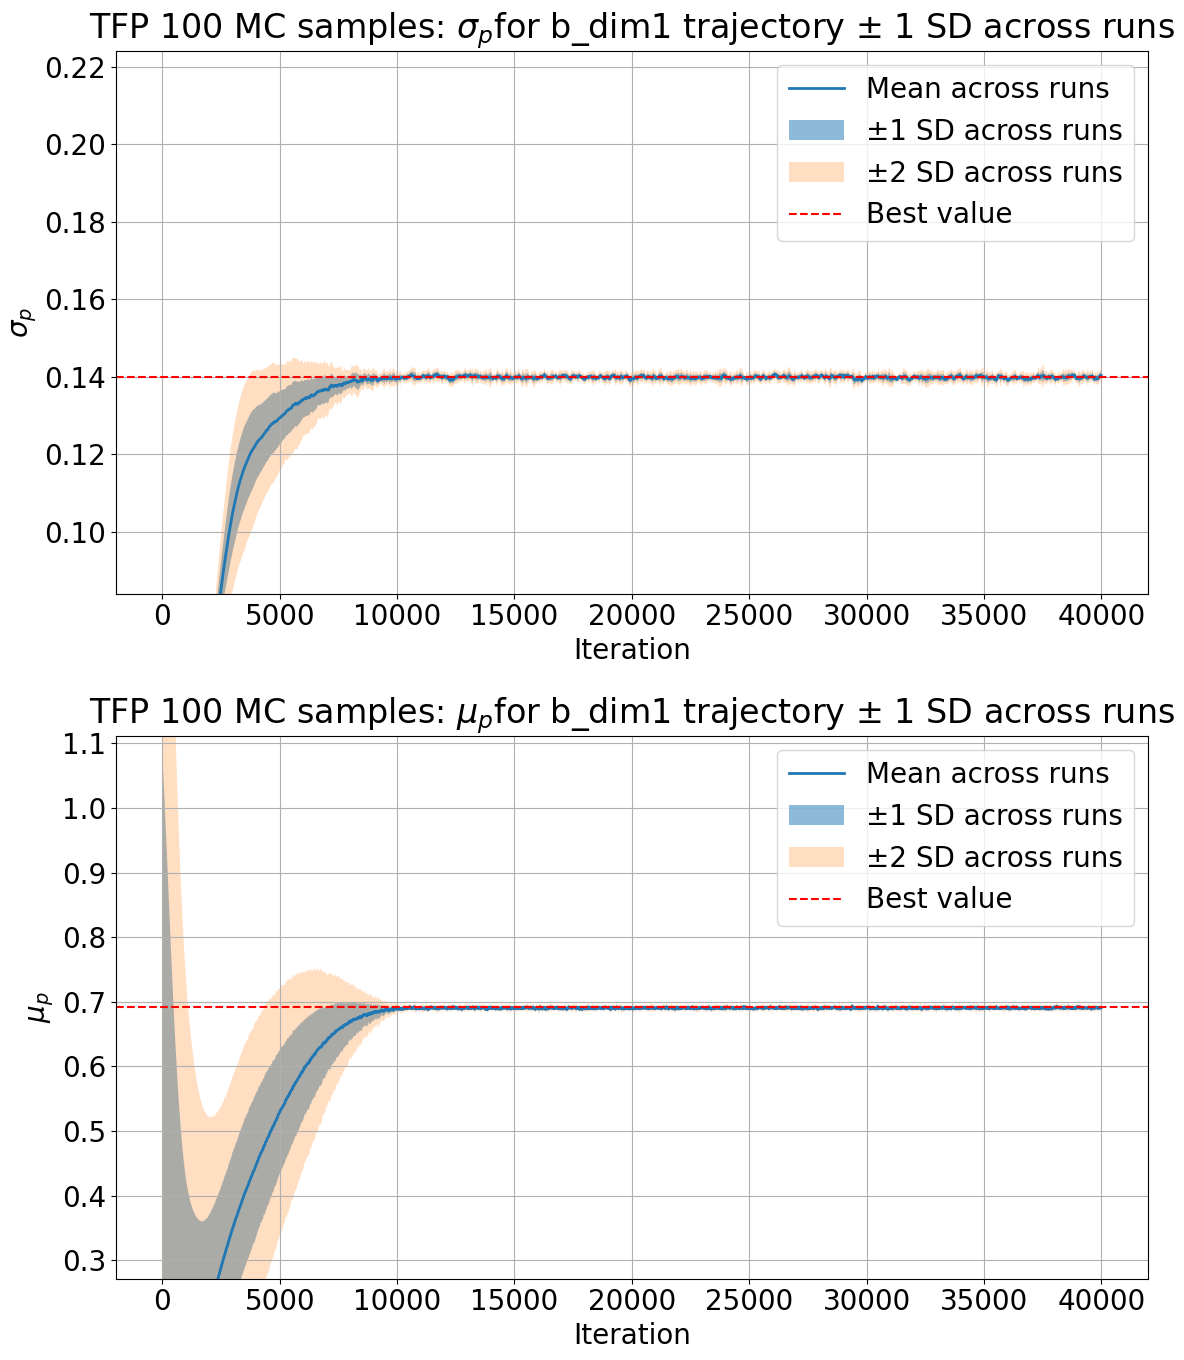

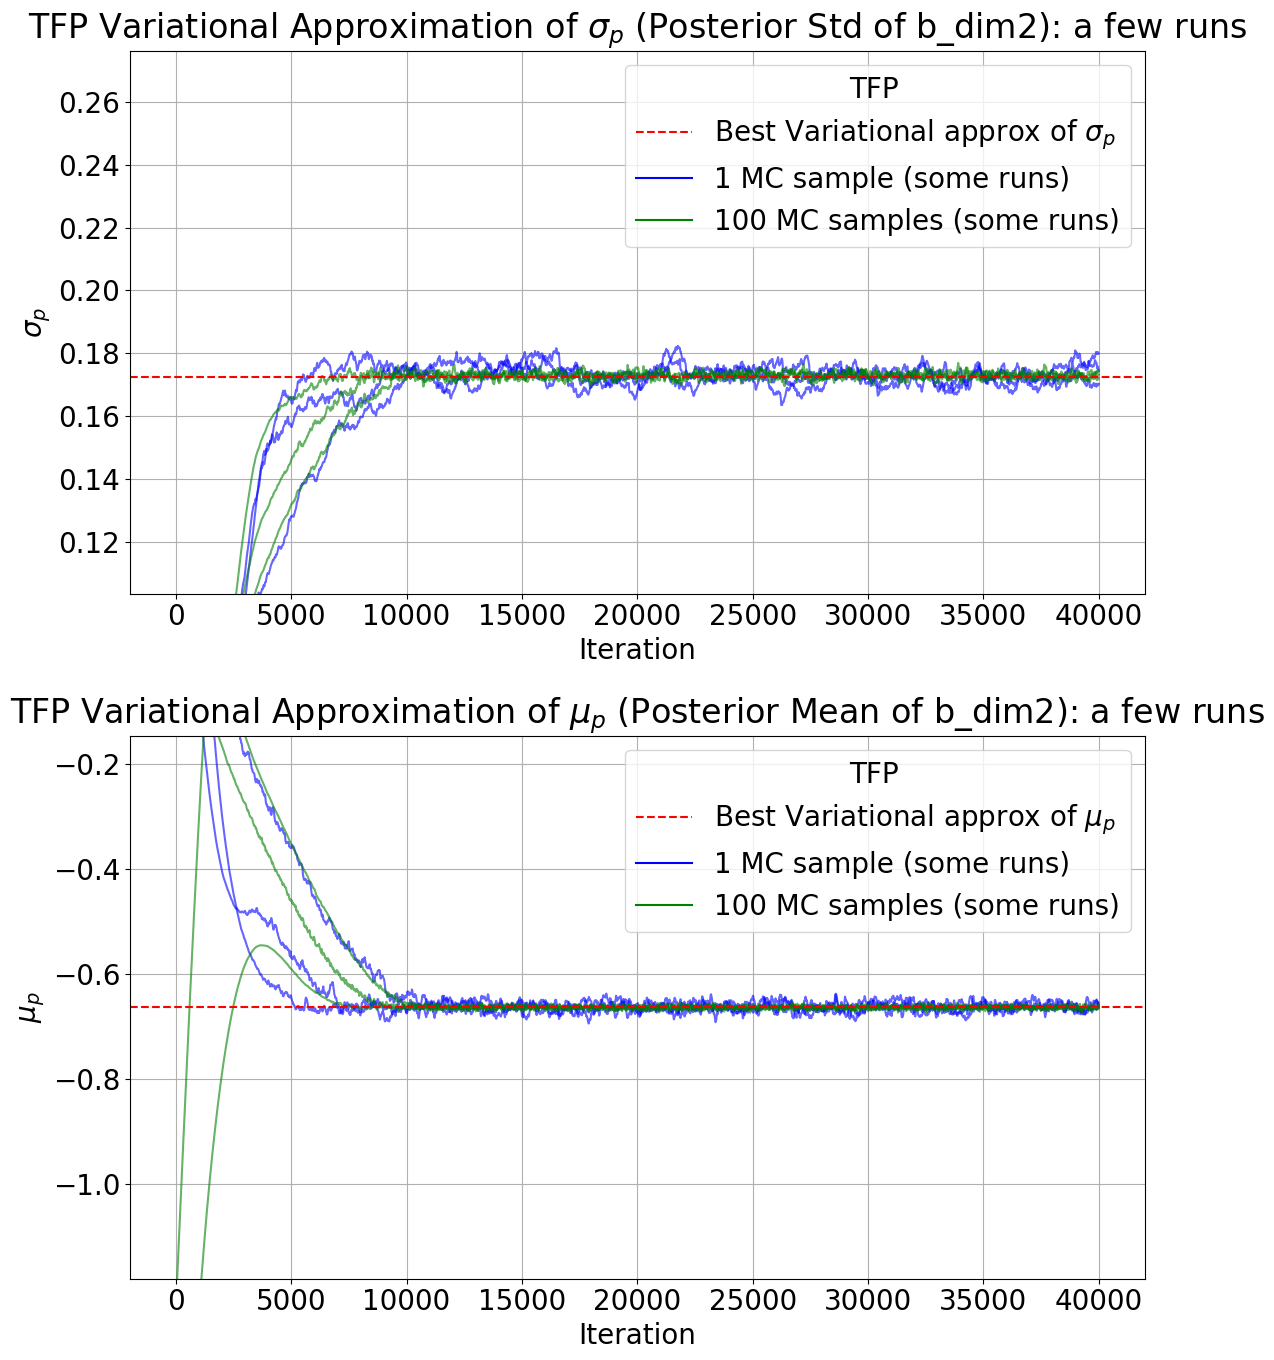

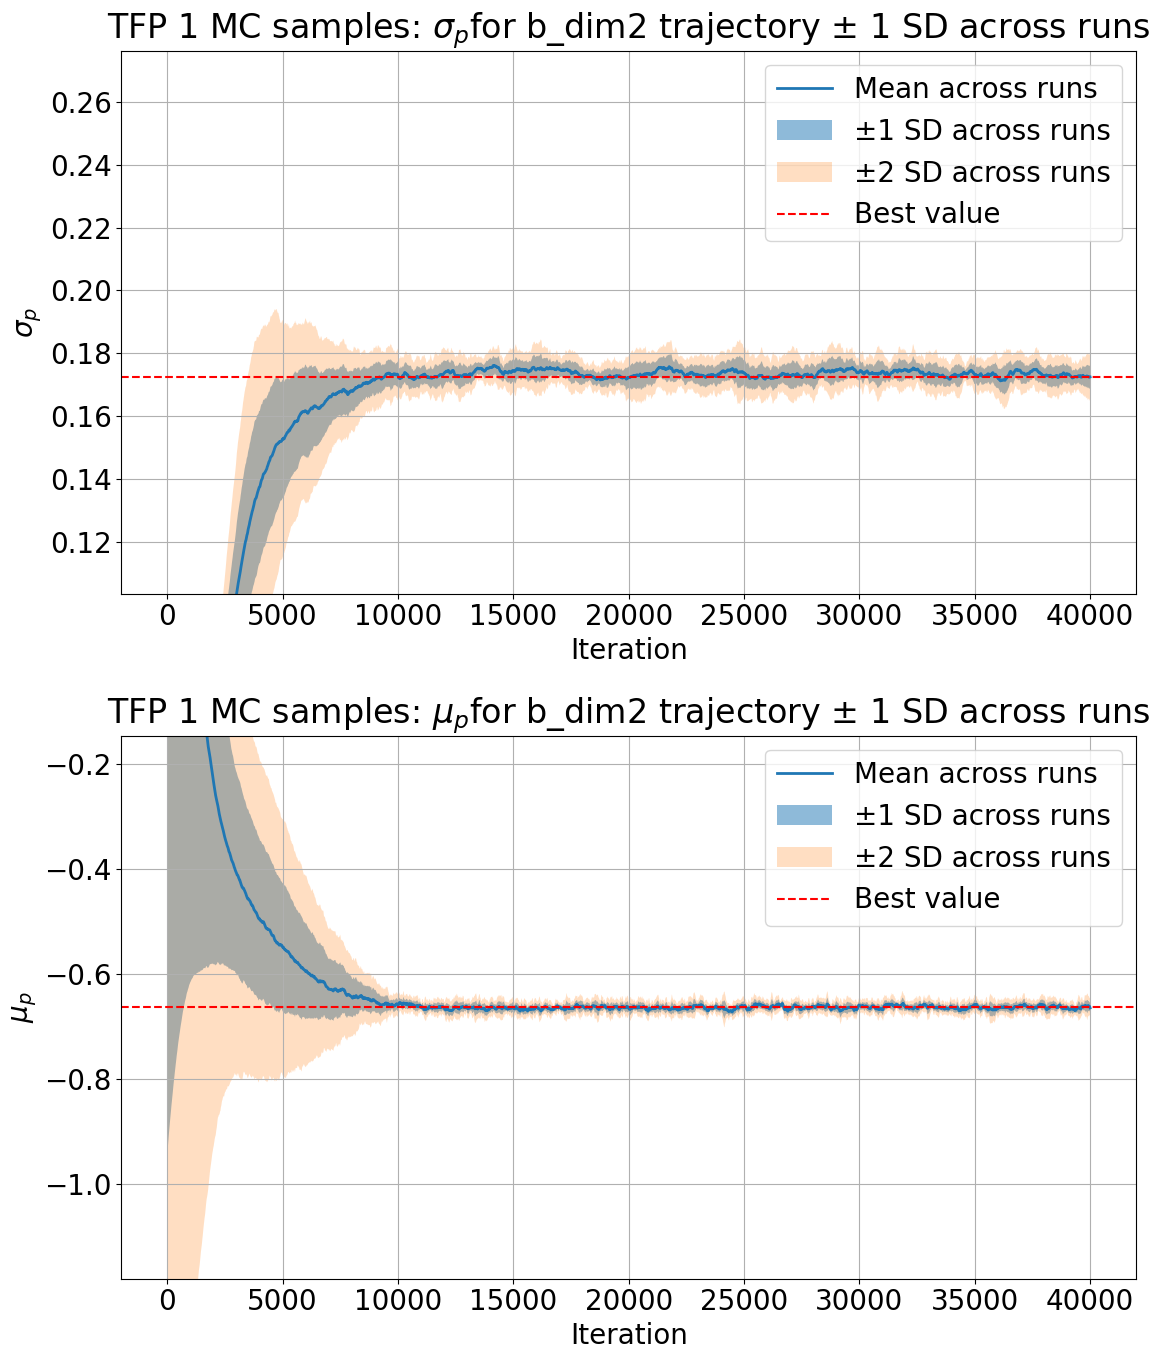

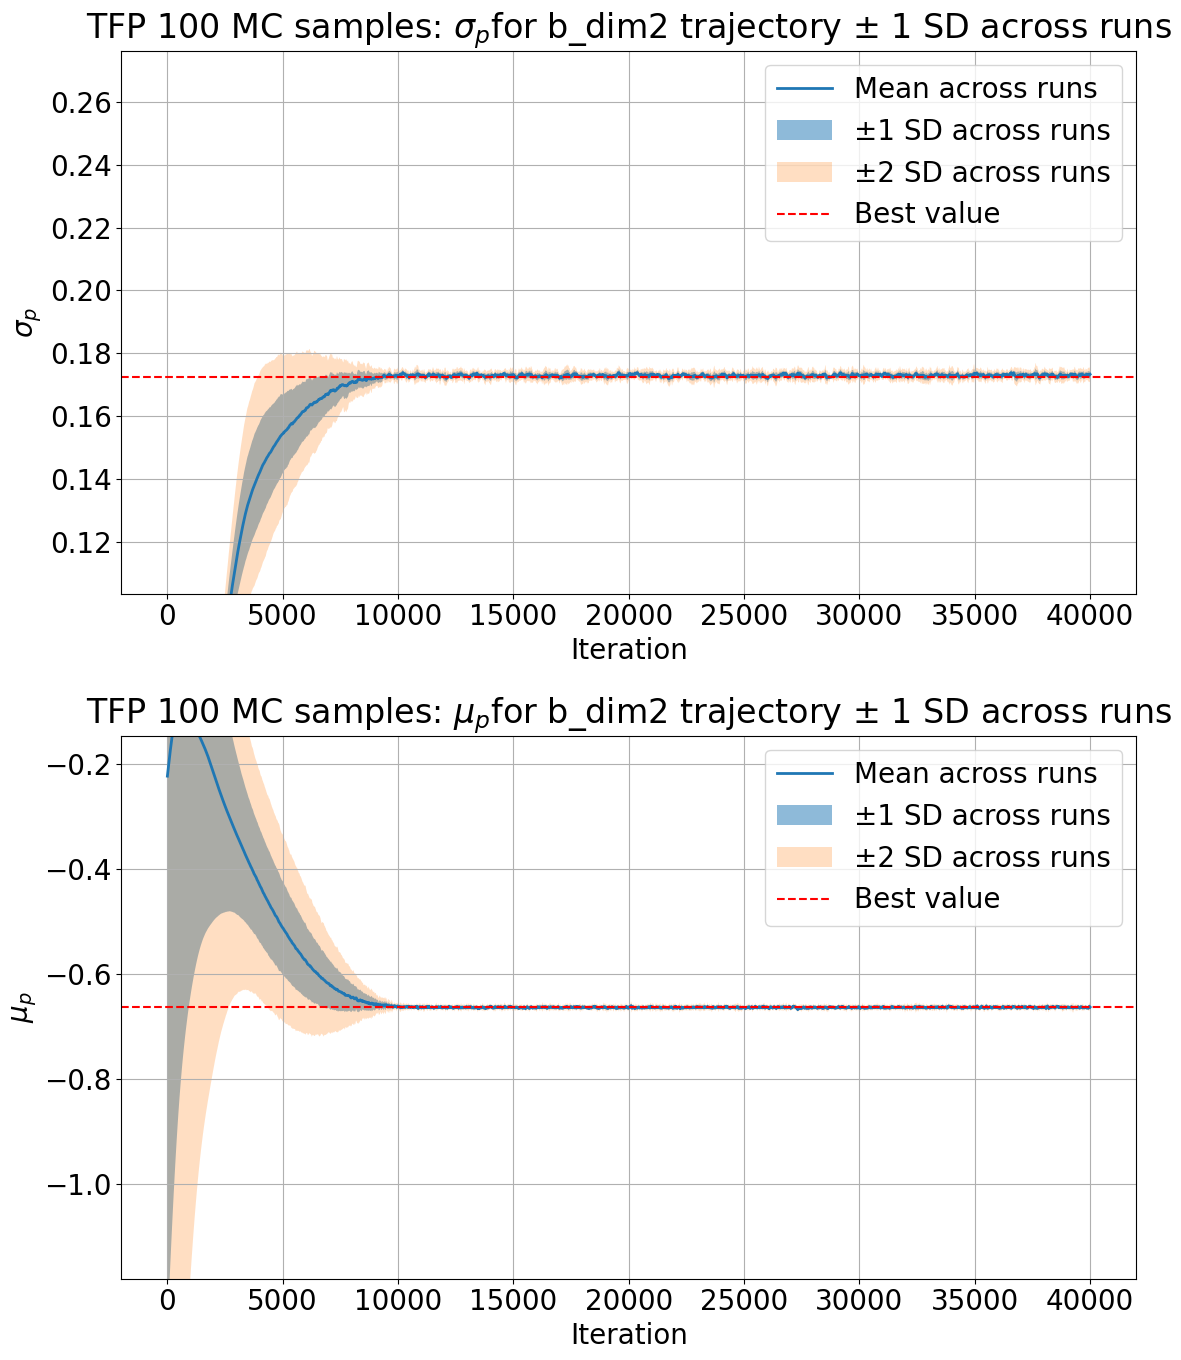

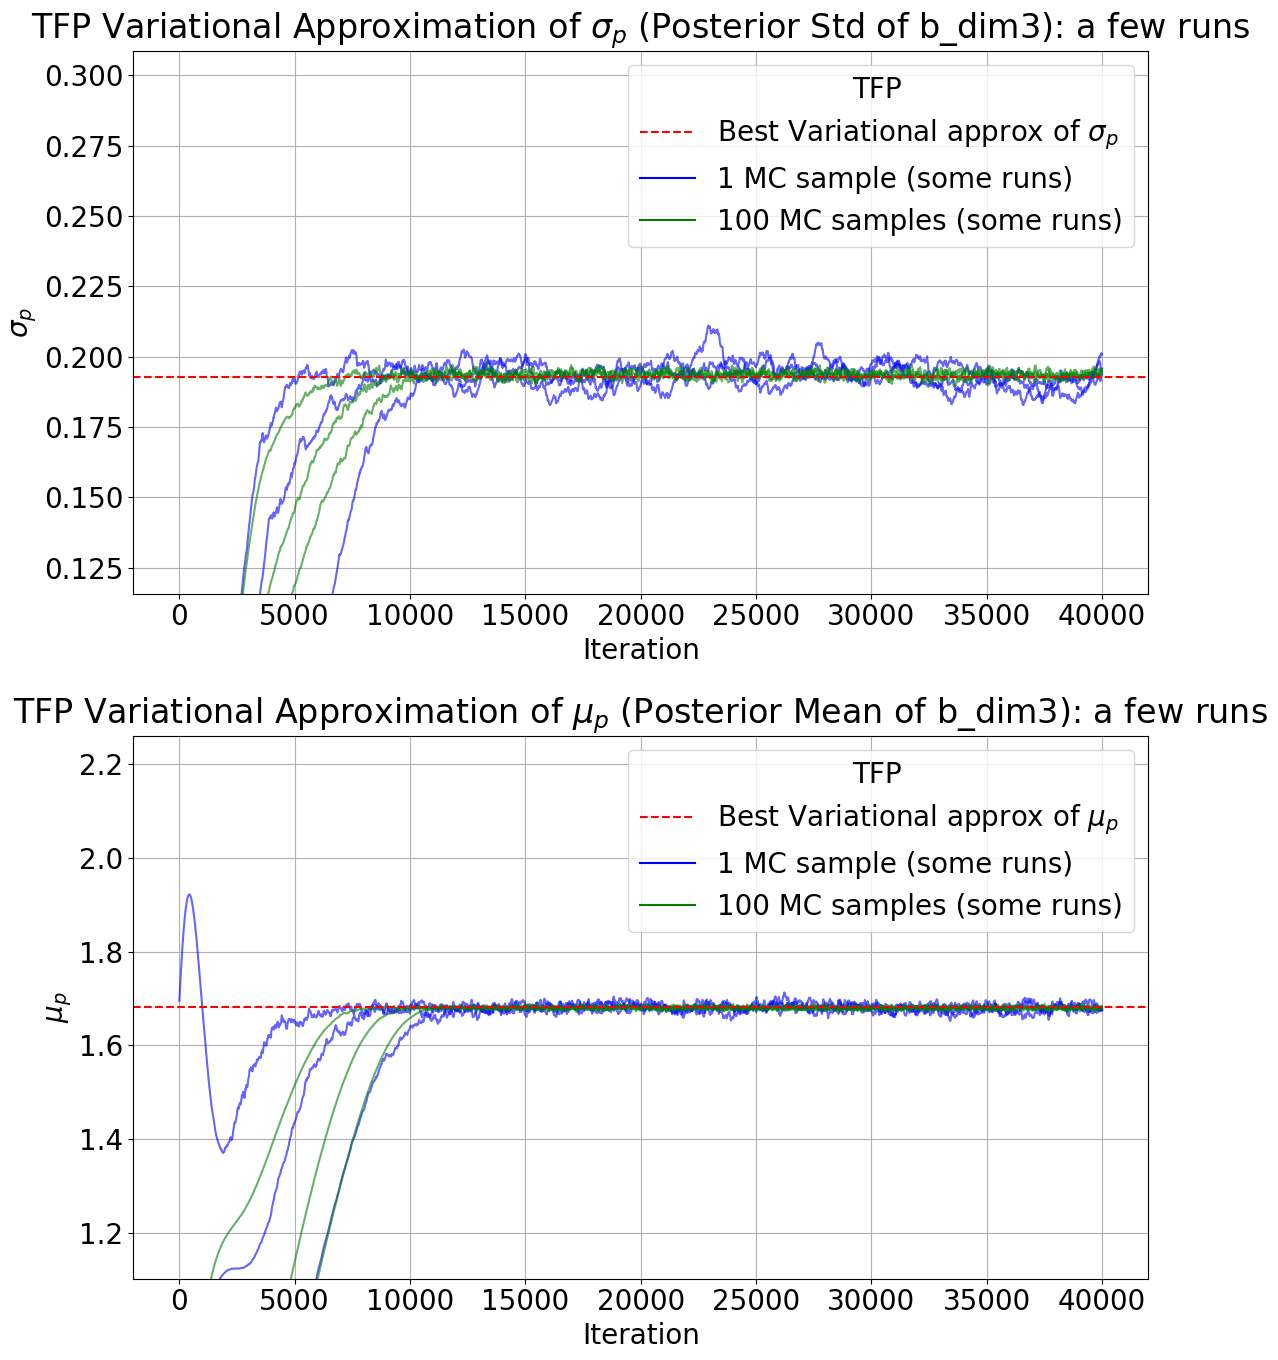

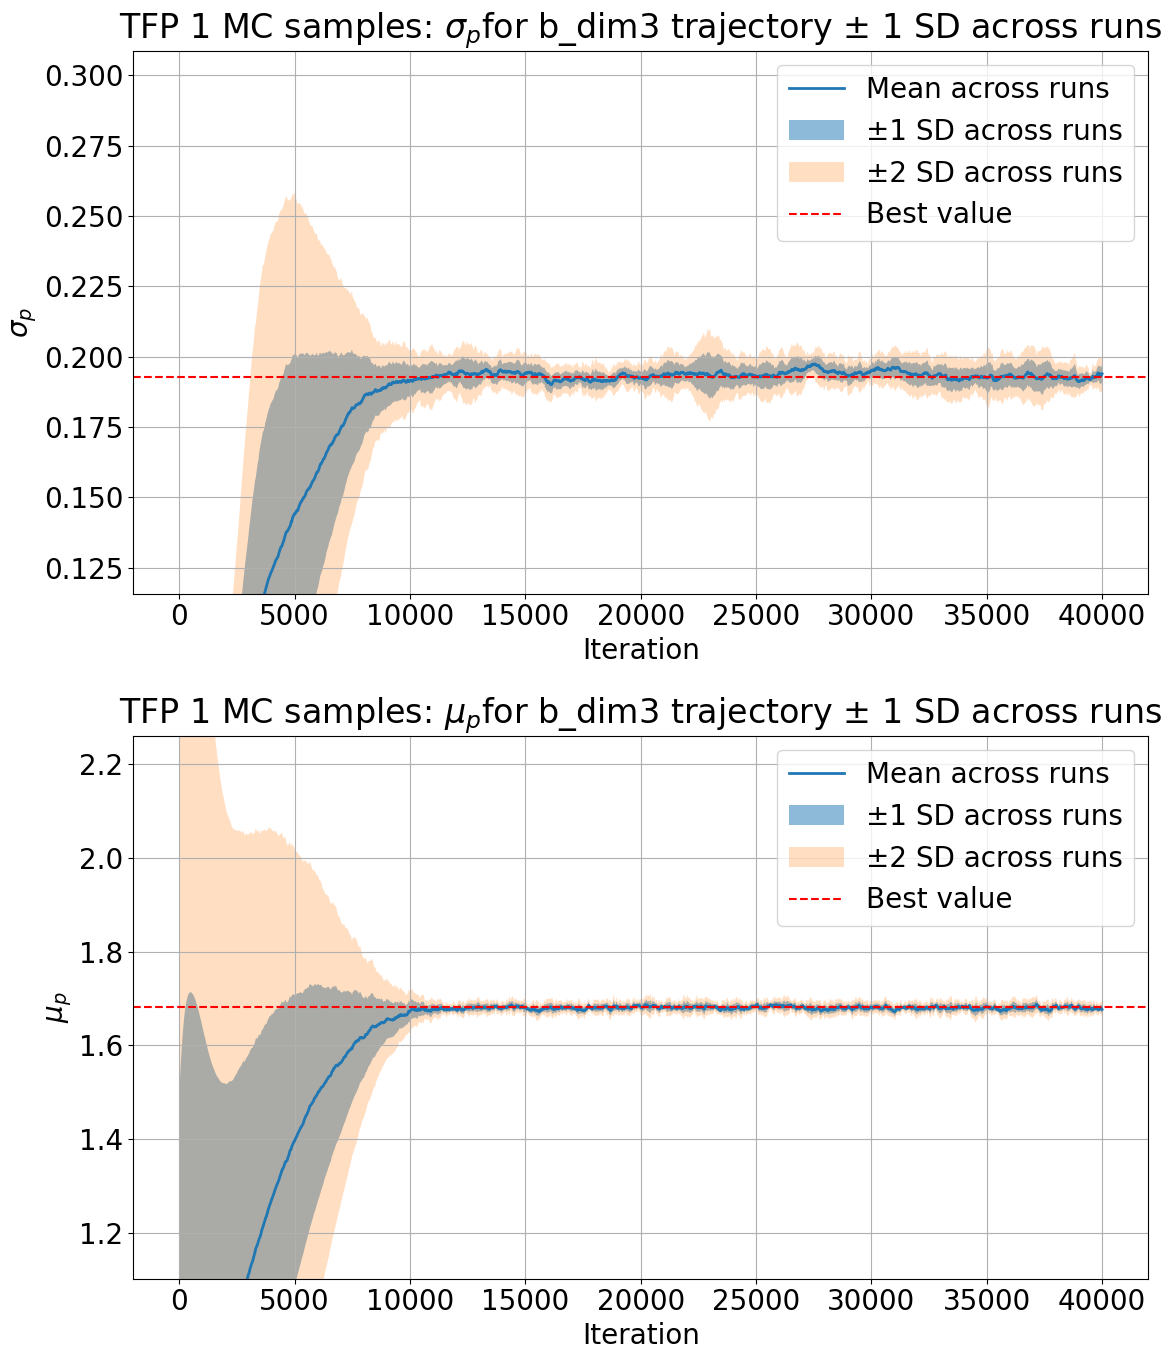

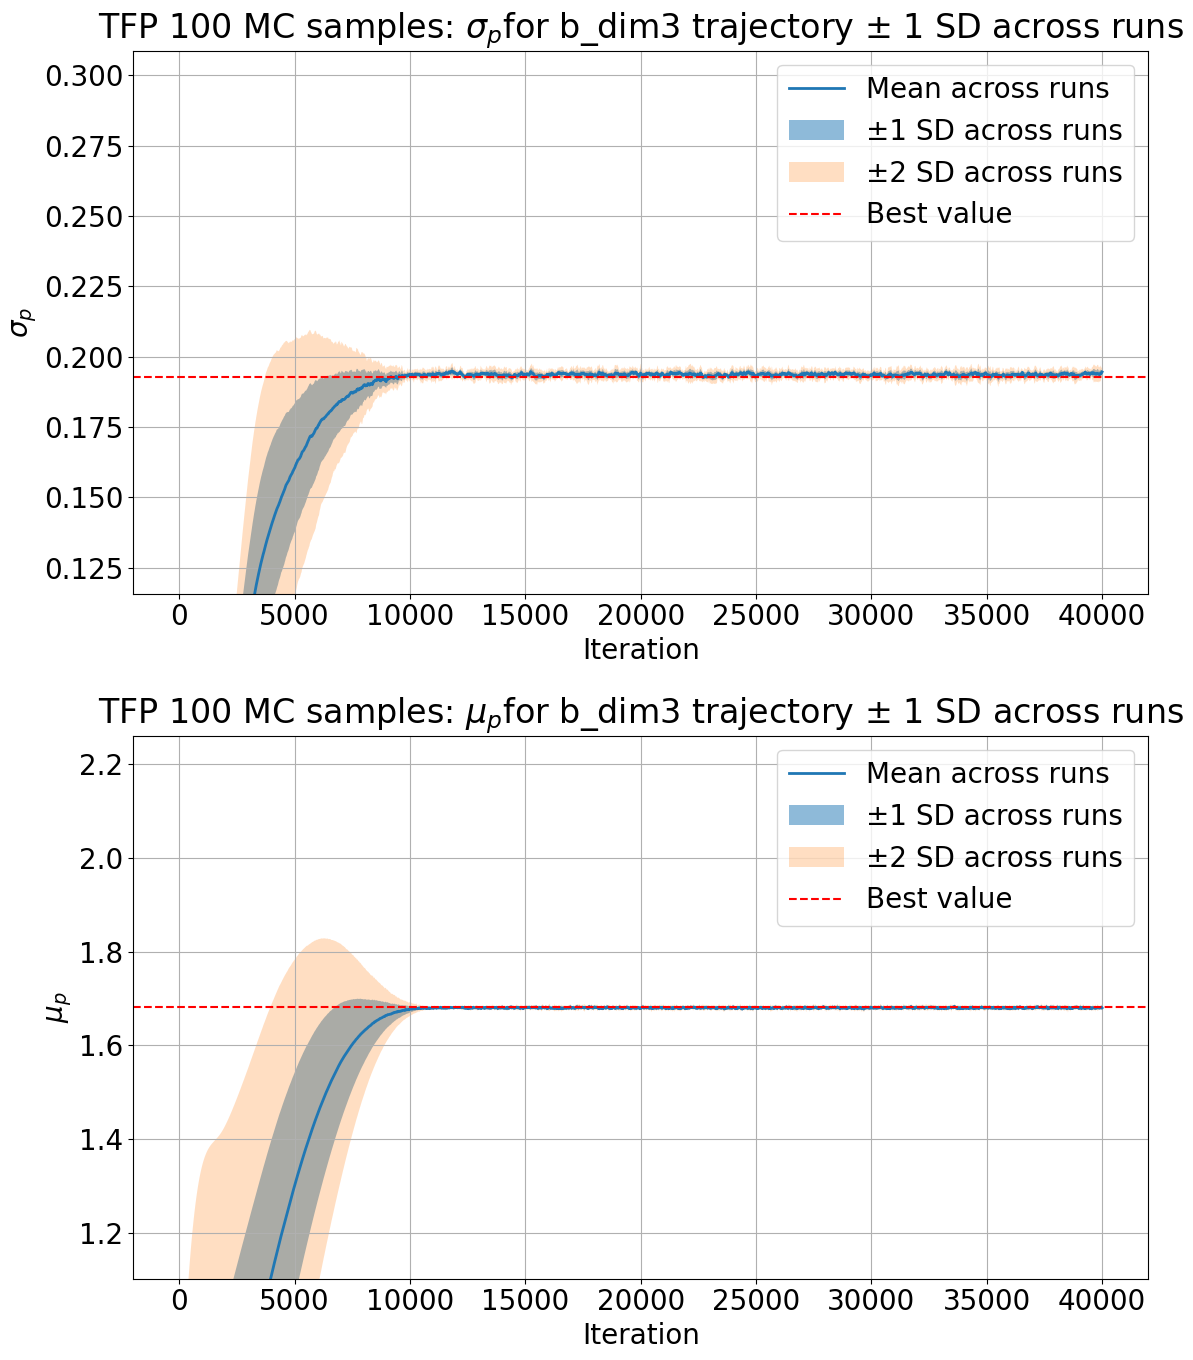

In [12]:
best_mean = best_reference["mean"].to_numpy()
best_std = best_reference["sd"].to_numpy()

plot_some_dims_multid(
    single_means, single_stds, multi_means, multi_stds,
    best_mean, best_std,
    param_name="b",
    dim=dim,
    which_dims=list(range(dim)),
    k=min(3, n_restarts),
    label_prefix="TFP ",
    iteration_stride=track_every
)


In [11]:
summary = pd.DataFrame({
    "parameter": labels,
    "single_mc_final_mean": single_means[:, -1, :].mean(axis=0),
    "single_mc_final_std": single_stds[:, -1, :].mean(axis=0),
    "multi_mc_final_mean": multi_means[:, -1, :].mean(axis=0),
    "multi_mc_final_std": multi_stds[:, -1, :].mean(axis=0),
    "best_variational_mean": best_reference["mean"].to_numpy(),
    "best_variational_sd": best_reference["sd"].to_numpy(),
})
summary


del single_means, single_stds, multi_means, multi_stds
gc.collect()


72821